In [2]:
from pathlib import Path
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

#  Это позволяет отображать все строки в датасете
pd.set_option('display.max_rows', None)

In [3]:
RAW_PATH = Path(r"..\data\raw").as_posix()
PROCESSED_PATH = Path(r"..\data\processed").as_posix()
INTERIM_PATH = Path(r"..\data\interim").as_posix()
EXTERNAL_PATH = Path(r"..\data\external").as_posix()

assert (
    os.path.isdir(RAW_PATH)
    and os.path.isdir(PROCESSED_PATH)
    and os.path.isdir(INTERIM_PATH)
    and os.path.isdir(EXTERNAL_PATH)
)

# Часть 1

## Подгрузим датасет из задания №1

In [7]:
# Загрузим датасет из csv

news_df = pd.read_csv(Path(RAW_PATH / Path("news.csv")))
news_df.tail()

,text,date
1881,Турецкие рынки резко рухнули после задержания ...,2025-03-19
1882,Россия и Украина провели обмен военнослужащими...,2025-03-19
1883,Инфляционные ожидания россиян в марте снизилис...,2025-03-19
1884,Генпрокуратура проверит работу МЧС и его подра...,2025-03-19
1885,Национальный союз защиты прав потребителей поп...,2025-03-19


## Проведем анализ пропущенных значений

In [9]:
# Проверим наличие пропущенных значений (NaN) в датасете

news_df[news_df.isnull().any(axis=1)]

,text,date
1124,NaN,2025-04-04
1125,NaN,2025-04-04
1126,NaN,2025-04-04
1165,NaN,2025-04-03
1166,NaN,2025-04-03
1167,NaN,2025-04-03
1168,NaN,2025-04-03
1169,NaN,2025-04-03
1197,NaN,2025-04-03
1198,NaN,2025-04-03


**Необходимо узнать время поста чтобы найти него в группе и сделать предположения почему текст отсутствует**

In [ ]:
forbes_df = pd.read_csv(
    Path(RAW_PATH / Path("forbes-news.csv")), usecols=["date", "text"]
)

# Проверим наличие пропущенных значений (NaN) в датасете

forbes_df['date'] = pd.to_datetime(forbes_df['date'])

# Предварительно сгруппируем по дате т.к. в датасете есть дубли
sorted_forbes_df_with_nulls = forbes_df[forbes_df.isnull().any(axis=1)].groupby('date').first().reset_index()
sorted_forbes_df_with_nulls



In [23]:
# Добавим столбец с описанием отсутствия поста
sorted_forbes_df_with_nulls["description"] = ""   


In [35]:
sorted_forbes_df_with_nulls.loc[0, ("description")] = "Поста не существет, возможно он был удален"    
sorted_forbes_df_with_nulls.loc[1, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[2, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[3, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[4, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[5, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[6, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[7, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[8, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[9, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[10, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[11, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[12, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[13, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[14, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[15, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[16, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[17, ("description")] = "Поста не существет, возможно он был удален"
sorted_forbes_df_with_nulls.loc[18, ("description")] = "Поста не существет, возможно он был удален"


In [36]:
sorted_forbes_df_with_nulls

,date,text,description
0,2025-03-19 16:34:37+00:00,None,"Поста не существет, возможно он был удален"
1,2025-03-21 12:08:28+00:00,None,"Поста не существет, возможно он был удален"
2,2025-03-21 16:41:09+00:00,None,"Поста не существет, возможно он был удален"
3,2025-03-24 14:52:34+00:00,None,"Поста не существет, возможно он был удален"
4,2025-03-24 16:37:54+00:00,None,"Поста не существет, возможно он был удален"
5,2025-03-25 16:39:05+00:00,None,"Поста не существет, возможно он был удален"
6,2025-03-26 17:46:28+00:00,None,"Поста не существет, возможно он был удален"
7,2025-03-28 10:33:44+00:00,None,"Поста не существет, возможно он был удален"
8,2025-03-28 12:51:49+00:00,None,"Поста не существет, возможно он был удален"
9,2025-03-31 12:32:55+00:00,None,"Поста не существет, возможно он был удален"


In [15]:
forbes_df[forbes_df.isnull().any(axis=1)].shape

(72, 2)

**Была произведена попытка найти каждый пост по дате и времени с целью понять почему текст отсутствует. Но найти закономерность не удалось. Посты просто не существуют**


## Проведем анализ выбросов

В качестве признака возьмем количество токенов в тексте

In [8]:
# Удаляем строки, где столбец "text" содержит NaN значения
print(f"Пустых строк:{news_df['text'].isna().sum()}")
news_df = news_df.dropna(subset=["text"])
print(f"Размер датасета после удаления NaN: {news_df.shape[0]} строк")



Пустых строк:72
Размер датасета после удаления NaN: 1814 строк


In [12]:
# Сохраним датасет в формате txt
news_df['text'].to_csv(os.path.join(INTERIM_PATH, 'text.txt'), index=False, header=False)



In [15]:
# Возьмем BPE-алгоритм для токенизации

import sentencepiece as spm

spm.SentencePieceTrainer.Train('--input=../data/interim/text.txt --model_prefix=../models/bpe_model.vocab --vocab_size=8000 --model_type=bpe')


In [23]:
sp = spm.SentencePieceProcessor(model_file='../models/bpe_model.vocab.model')

news_df['tokens'] = news_df['text'].apply(lambda x: len(sp.encode(x, out_type=str)))

# news_df['text'] = news_df['text'].apply(lambda x: ' '.join(x))



C:\Users\vallo\AppData\Local\Temp\ipykernel_13172\1408930513.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(news_df["tokens"], color="g", shade=True)


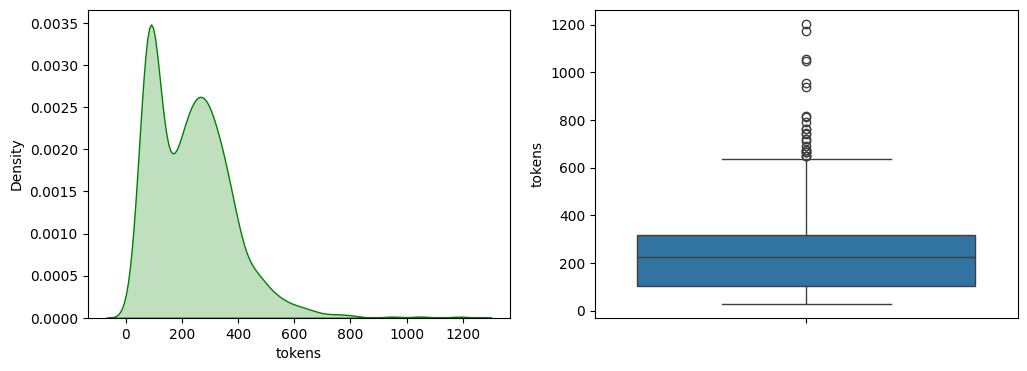

In [27]:
# Посмотрим на распределение количества токено в текстах

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(news_df["tokens"], color="g", shade=True)
plt.subplot(1, 2, 2)
sns.boxplot(news_df["tokens"])
plt.show()


In [28]:
# Посмотрим на выбросы с точки щрения стандарного отклонения (за пределами усов)

y_outliers = news_df[abs(zscore(news_df["tokens"])) >= 3]
y_outliers.shape[0]


18

In [31]:
# Среднее количество токенов в тексте

news_df["tokens"].mean()

np.float64(233.81422271223815)

In [29]:
# Посмотрим на тексты, попоавшие в выбросы с точки щрения стандарного отклонения

y_outliers

,text,date,tokens
36,Мировой опыт от обладателей Каннских львов и л...,2019-12-10,1204
140,"По итогам 2019 года, по сравнению с данными ис...",2019-12-10,711
231,"Телеведущий, пресс-секретарь «Роснефти» Михаил...",2019-12-11,720
344,"Члены онлайн-сообщества «Диссернет», позициони...",2019-12-11,1046
444,За спиной почетного патриарха неканонической П...,2019-12-11,672
475,Росгосцирк предложил Министерству Культуры Рос...,2019-12-12,815
492,Кредиторы компании бизнесмена Владимира Гусинс...,2019-12-12,673
495,Россия назвала необоснованными требования Ниде...,2019-12-12,689
564,"Начал вещание первый сервис, позволяющий росси...",2019-12-12,1174
580,"Компании «МегаФон», «Ростелеком», «ВымпелКом» ...",2019-12-12,764


**Видим, что новости, попавшие сюда - новости с большим количеством токенов $\Rightarrow$ не являются аномалиями**


# Часть 2

**Так как у нас выбросы - количество токенов в новостях, и они близки по степени, то смысла работать с ними нет. Да и к тому же, мы все равно будем получать агрегированный вектор токенов как смысловой вектор текста чтобы потом применять методы кластеризации.**

**Но при необходимости, для борьбы с выбросами, можно было бы воспользоваться следующими методами:**
- Ограничение максимального количества токенов. Данный метод может понизить информативность сообщения.
- Суммаризация текста до определенного количества токенов. Данный метод может сместить распределение токенов в другое смысловое пространство - изменить тему. 
- Заполнение токенами `PAD` всех текстов кроме того, что содержит максимальное количество. Выглядит костыльно, может запутать модель, если выбросы на порядки "сильнее" обычных значений.
- Автогенерация текста, как продолжение статьи для заполенения числом токенов до максимального количества. Может сместить распределение токенов в другое смысловое пространство - изменить тему, модель может галлюцинировать, дорого в промышленных масштабах.


**Для пропусков, лучшее, что можно сделать в этом случае - проанализировать причину и удалить строки с пропусками.**

# Часть 3

## Работа с выбросами

**Выбросы в данном случае - это новости с большим количеством токенов.**

**В нашем случае, выбросы не являются аномалиями, а являются частью распределения. Поэтому их просто оставляем.**

## Работа с пропусками

**Для пропусков, лучшее, что можно сделать в этом случае - проанализировать причину и удалить строки с пропусками.**



